## Notebook 3: Exploratory Data Analysis

In [1]:
import pandas as pd 
import numpy as numpy
import matplotlib.pyplot as plt 
import seaborn as sns 

plt.style.use("ggplot")

### Step 1: Load the Cleaned Dataset

In [2]:
file_path="../data/processed/online_retail_II_cleaned.csv"
df=pd.read_csv(file_path)
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


### Step 2: Dataset Overview

In [4]:
print("Shape:",df.shape)
print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape: (779425, 8)

Columns:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

Data Types:
Invoice          int64
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


### Step 3: Create Revenue Feature

Create a new `Revenue` column by multiplying the quantity of items sold with their unit price.

In [6]:
df["Revenue"]=df["Quantity"] * df["Price"]
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [7]:
df["Revenue"].describe()

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64

In [8]:
total_revenue=df["Revenue"].sum()
print(f"Total Revenue:£{total_revenue:,.2f}") 

Total Revenue:£17,374,804.27


**Observation:**

The company generated a total revenue of **£17,374,804.27** from completed transactions between December 2009 and December 2011.

### Step 5: Revenue by Country

In [11]:
country_revenue=(
    df.groupby("Country")["Revenue"]
    .sum().sort_values(ascending=False)
    )
country_revenue.head(10)

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Revenue, dtype: float64

### Step 6: Visualize Top 10 Countries by Revenue

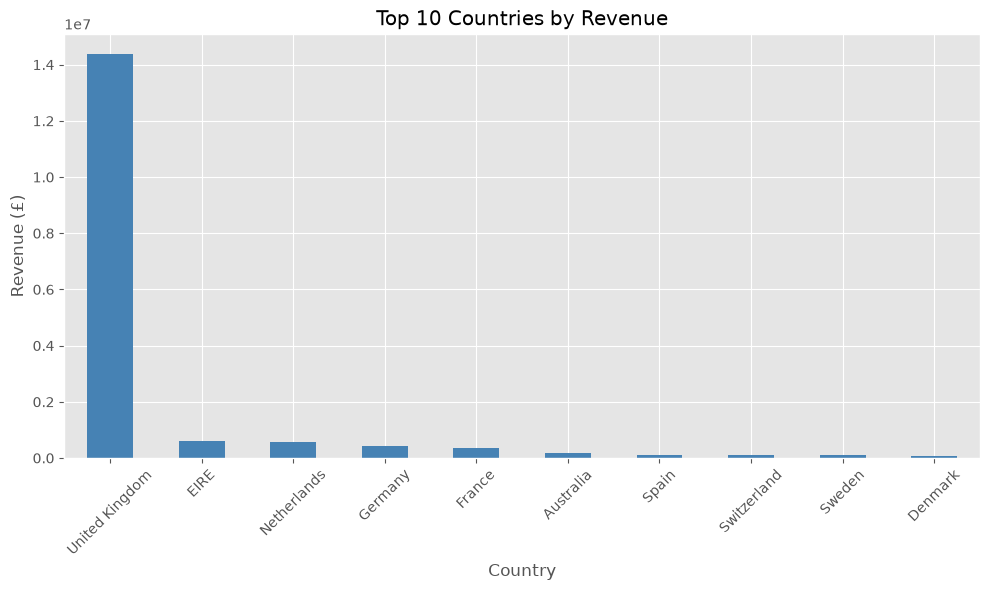

In [13]:
top10 = country_revenue.head(10)

plt.figure(figsize=(10, 6))

top10.plot(kind="bar", color="steelblue")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()



plt.show()

The **United Kingdom** generated the highest revenue by a large margin.

### Top 10 Products by Revenue

Analyze the products that generate the highest revenue.

In [15]:
product_revenue=(
    df.groupby("Description")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

top_products=product_revenue.head(10)
top_products

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: Revenue, dtype: float64

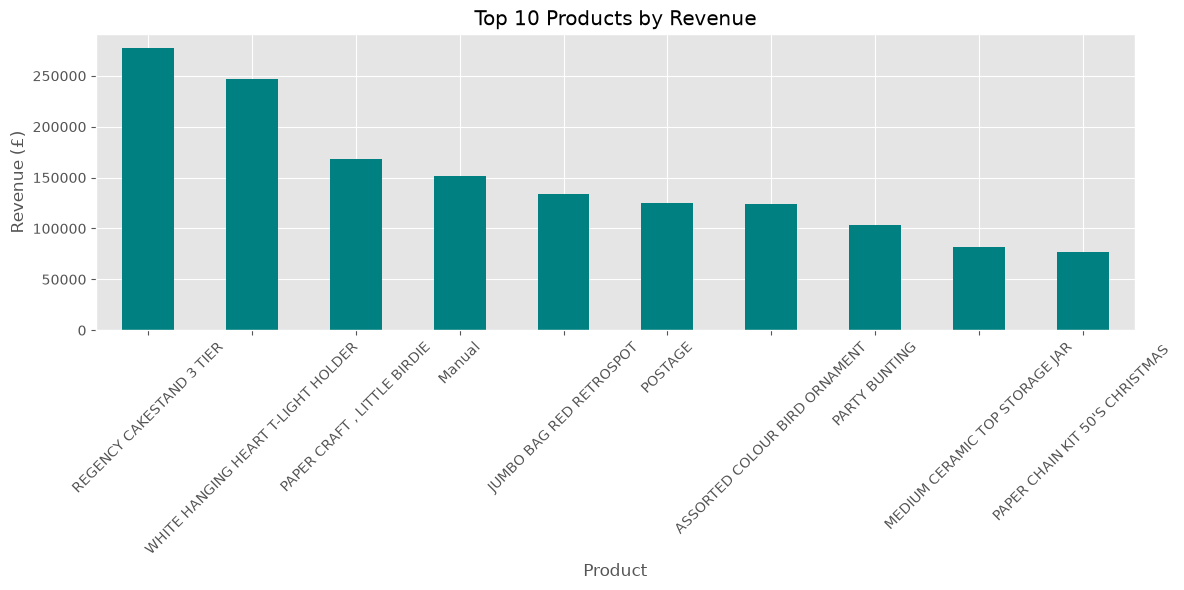

: 

In [ ]:
plt.figure(figsize=(12,6))

top_products.plot(kind="bar",color="teal")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

- The chart shows the products that generated the highest revenue.
- A few products contribute a large share of the total revenue, while the remaining products generate comparatively lower sales.
- These products can be considered key revenue drivers for the business.